# Double working precision in PyCBC: numerical error and H1 trigger selection

PyCBC tests a candidate gravitational-wave signal's consistency across frequency bins. With complex64 correlations, its selected-point CPU chi-square routine repeatedly rounds rotations and sums to float32. This notebook compares the original implementation with a change that uses double working precision while retaining complex64 inputs and float32 outputs.

First, three saved samples illustrate the numerical error. Then a complete search of public LIGO Hanford (H1) strain demonstrates changed trigger decisions at a **pre-existing NewSNR cut of 5**. The larger bank was prepared before this investigation; neither the threshold nor the strain amplitude was adjusted to cause a crossing. This is evidence of single-detector trigger selection changing, not of a lost or gained astrophysical detection.

Both searches use 2048 Hz sampling, 512-second segments, 16 chi-square bins and IMRPhenomD templates. Within each comparison, conditioning, correlations, bins, SNR and normalization stay fixed. The CPU routine being tested performs no FFT.

## Setup

Run from this directory with PyCBC, NumPy, SciPy, pandas, Matplotlib, Cython, Jupyter and a C++ compiler installed. Keep the helper, `kernels/`, `selection/`, timing CSV and `../data/` files at their repository paths. **Restart Kernel and Run All**. Only the original and arithmetic-patch Cython kernels are built, using PyCBC's build flags. The notebook replays saved inputs; no strain download or full search is required. [Original capture](../data/point-input-05.json) · [Full-search provenance and reproduction](selection/README.md).

The initial three-sample capture had the largest discrepancy among six saved calls (11 samples) in a 32-template search. It illustrates the error, not its prevalence.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio:")

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import ifft
from pycbc.types import Array
from pycbc.events.ranking import newsnr
from cpu_chisq_review import kernels, load_capture, reference_power, plot_style

plot_style()
modules = kernels(("upstream", "arithmetic"))
data = load_capture()
corr, snr = data['corr'], data['snr']
points, bins = data['indices'], data['bins']
norm = float(data['norm'])
N, p = len(corr), len(bins) - 1
snr_power = (snr.conj() * snr).real
manifest = json.loads(Path('kernels/manifest.json').read_text())
print('Upstream source:', manifest['upstream_commit'])
print('Samples:', points.tolist(), '; widest bin:', int(np.diff(bins).max()))
assert np.array_equal(points, points.astype(np.float32).astype(points.dtype))
print('All captured indices are exactly representable as float32.')

Upstream source: 454ee900e6faca88a066e71ade489fca9fb221a5
Samples: [484954, 619888, 656106] ; widest bin: 373308
All captured indices are exactly representable as float32.


## Independent reference and actual before/after results

Let qᵦ be the rotated sum in bin b, S = Σᵦ|qᵦ|², and p the number of bins. The statistic is **χ² = (p S − |snr|²) × norm²**. Here `snr` is the captured unnormalized matched-filter sum and `norm` its SNR normalization. The reference evaluates every phase explicitly in complex128 and checks against separate complex128 inverse FFTs. Both preserve the captured SNR-power term, so this evaluates the selected-point stage, not every source of numerical error in a search.

The patch results below retain the actual float32 output and final wrapper arithmetic for complex64 inputs. `verify_installed.py` checked these expressions and archived-kernel outputs against the original and patched public PyCBC calls.

In [2]:
def fft_reference_power(correlation, samples, edges):
    power = np.zeros(len(samples))
    for lo, hi in zip(edges[:-1], edges[1:]):
        band = np.zeros(len(correlation), dtype=np.complex128)
        band[lo:hi] = correlation[lo:hi]
        power += abs((len(correlation) * ifft(band))[samples])**2
    return power

reference = reference_power(corr, points, bins)
fft_power = fft_reference_power(corr, points, bins)
np.testing.assert_allclose(reference, fft_power, rtol=1e-11)
reference_chisq = (p * reference - snr_power) * norm**2
value = Array(corr, copy=False)
powers = {label: module.shift_sum(value, points, bins)
          for label, module in modules.items()}
chisq = {label: (p * power - snr_power) * norm**2
         for label, power in powers.items()}
errors = {label: 100 * (chi / reference_chisq - 1)
          for label, chi in chisq.items()}
np.testing.assert_allclose(chisq['arithmetic'], reference_chisq, rtol=6e-6)
assert max(abs(errors['arithmetic'])) < max(abs(errors['upstream']))
table = pd.DataFrame(errors, index=points)
table.index.name = 'sample'
table.insert(0, 'reference chi-square', reference_chisq)
print('Remaining columns: signed chi-square error (% of reference).')
display(table.style.format(precision=7))
print('Max |direct / FFT reference difference|:',
      np.max(abs(reference / fft_power - 1)))

Remaining columns: signed chi-square error (% of reference).


,reference chi-square,upstream,arithmetic
sample,,,
484954,33.3259417,-0.0281664,-0.0001679
619888,36.3370953,-0.1503483,-0.0002152
656106,42.9809734,0.1721608,0.0005033


Max |direct / FFT reference difference|: 2.220446049250313e-16


## How error develops across frequency bins

Both curves below use the actual compiled kernels, adding complete bins from left to right for sample 656106, the largest-discrepancy sample in this capture. The y-axis expresses the accumulated bin-power error as a percentage of the **final reference chi-square**; intermediate points are not partial chi-square values. Common float64 final arithmetic isolates error inside the kernel. The table above also includes the public wrapper's float32 rounding.

This comparison measures the effect of the entire change to double working precision. It does not allocate separate shares to rotations and summation: the [phase control](phase.ipynb) and [accumulation controls](accumulation.ipynb) isolate those mechanisms using known-answer inputs.

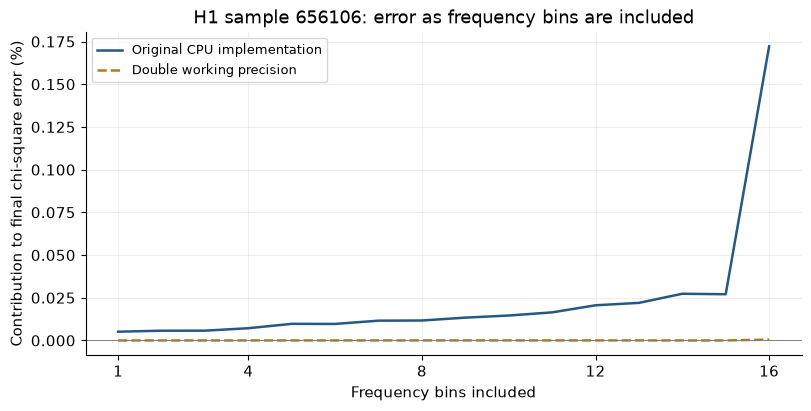

upstream: maximum absolute relative chi-square error = 0.1721608%
arithmetic: maximum absolute relative chi-square error = 0.0005033%


In [3]:
reference_bins = np.array([reference_power(corr, points, bins[j:j+2])
                           for j in range(p)]).T
reference_cumulative = np.cumsum(reference_bins, axis=1)
cumulative = {label: np.column_stack([
    module.shift_sum(value, points, bins[:j+2]) for j in range(p)])
    for label, module in modules.items()}
contribution = {label: 100*p*norm**2*(power-reference_cumulative) /
                reference_chisq[:, None] for label, power in cumulative.items()}
j = int(np.flatnonzero(points == 656106)[0])
x = np.arange(1, p+1)
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
for label, title, color, style in [
        ('upstream', 'Original CPU implementation', '#245885', '-'),
        ('arithmetic', 'Double working precision', '#B77818', '--')]:
    ax.plot(x, contribution[label][j], label=title, color=color, ls=style)
ax.axhline(0, color='0.5', lw=.7)
ax.set(title='H1 sample 656106: error as frequency bins are included',
       xlabel='Frequency bins included',
       ylabel='Contribution to final chi-square error (%)',
       xticks=[1, 4, 8, 12, 16])
ax.legend(fontsize=9)
plt.show()
for label in modules:
    print(f'{label}: maximum absolute relative chi-square error = '
          f'{max(abs(errors[label])):.7f}%')

## Selection at an unchanged search cut

The original **32-template** search gives 89 candidates before the NewSNR cut and retains the same 77 with either kernel. The three samples above therefore do not demonstrate a selection change.

To test a larger population, we used an existing **6,144-template** subset of the public O2 bank, prepared on 2026-09-20 using fixed mass/spin cuts and a fixed seed. The 2026-09-22 run keeps the original H1 data, **raw SNR ≥ 5.5**, **NewSNR ≥ 5**, and all other search settings. All 1,904 valid detector seconds and all templates are processed; we did not stop at the first crossing.

The observer returns unmodified CPU results throughout filtering and clustering. At the final cut it applies PyCBC's actual `EventManager.newsnr_threshold` to two copies of the same clustered events, replacing only chi-square in the second. Earlier clustering uses raw SNR; this command enables no other chi-square cut or later ranking selection. The table includes **every changed decision**, with an independent reference checked after float32 event storage. Counts describe this one bank/data segment, not a population rate.

In [4]:
import hashlib

evidence = Path('selection')
provenance = json.loads((evidence/'provenance.json').read_text())
for filename, expected in provenance['sha256'].items():
    assert hashlib.sha256((evidence/filename).read_bytes()).hexdigest() == expected

for run in provenance['runs']:
    population = pd.read_csv(evidence/f"candidates-{run['templates']}.csv.gz",
                             float_precision='round_trip')
    assert len(population) == run['before_cut']
    for label in ['upstream', 'arithmetic']:
        # EventManager divides float32 chi-square by its int64 DOF array.
        computed = newsnr(population['rho'].to_numpy(dtype=np.float32),
                          population[label].to_numpy(dtype=np.float32) /
                          population['dof'].to_numpy(dtype=np.int64))
        np.testing.assert_allclose(computed, population[label+'_newsnr'], rtol=1e-14)
        assert np.array_equal(computed >= 5, population[label+'_pass'])
        assert (computed >= 5).sum() == run[label+'_kept']
    old, new = population.upstream_pass, population.arithmetic_pass
    assert ((~old) & new).sum() == run['gained']
    assert (old & (~new)).sum() == run['lost']

population = pd.read_csv(evidence/'candidates-6144.csv.gz', float_precision='round_trip')

counts = pd.DataFrame(provenance['runs'])
display(counts[['templates', 'before_cut', 'upstream_kept',
                'arithmetic_kept', 'gained', 'lost']])
changed = population[population.upstream_pass != population.arithmetic_pass]
assert len(changed) == int(counts.loc[counts.templates == 6144, 'changed'].iloc[0])
assert np.array_equal(changed.reference_float32_newsnr >= 5, changed.arithmetic_pass)
display(changed[['template_hash', 'gps', 'rho', 'upstream_newsnr',
                 'arithmetic_newsnr', 'reference_float32_newsnr',
                 'upstream_pass', 'arithmetic_pass']].style.format({
    'gps': '{:.6f}', 'rho': '{:.6f}', 'upstream_newsnr': '{:.7f}',
    'arithmetic_newsnr': '{:.7f}', 'reference_float32_newsnr': '{:.7f}'}))

,templates,before_cut,upstream_kept,arithmetic_kept,gained,lost
0,32,89,77,77,0,0
1,6144,16378,14334,14335,4,3


,template_hash,gps,rho,upstream_newsnr,arithmetic_newsnr,reference_float32_newsnr,upstream_pass,arithmetic_pass
142,107514562193601506,1187008427.809082,5.682845,4.9986619,5.0001907,5.0001830,False,True
1502,3817250741517076302,1187007822.729980,5.556757,5.0007998,4.9992452,4.9992311,True,False
7426,8977059625468206652,1187008670.545410,5.556389,5.0013263,4.9980673,4.9980815,True,False
9720,3526442591276109755,1187007265.239258,5.621402,4.9992921,5.0014379,5.0014574,False,True
13211,2674380675434408664,1187008145.628906,5.527143,5.0001535,4.9996228,4.9996187,True,False
14071,-643334193478004959,1187007473.805176,5.629531,4.9988600,5.0002382,5.0002433,False,True
15829,-2955860346836625822,1187008841.344238,5.781146,4.9987789,5.0007372,5.0007157,False,True


## Replay the first naturally occurring crossing

This is the first changed event in the run's template/event order, not the largest error. Its raw SNR is about **5.683**, comfortably above the raw-SNR cut of 5.5. The numerical discrepancy changes whether its **reweighted** SNR clears the already fixed cut of 5. With errors of this size, a selection change involves a candidate near the cut; the evidence here is that it occurs in unaltered detector data without moving the cut.

Recompute all three samples in the captured call, then show this event. The reference uses explicit complex128 Fourier sums and was independently cross-checked against per-bin complex128 inverse FFTs. The final reference chi-square is rounded into the same float32 event storage before ranking. CPU/compiler differences can slightly change the original result; the saved Linux population above and this local replay are distinguished.

Max |direct / FFT reference difference|: 5.551115123125783e-16
Template hash: 107514562193601506 ; GPS: 1187008427.809082


,chi-square,NewSNR,retained
upstream,44.74625778,4.99865502,False
arithmetic,44.71048737,5.00019074,True
reference,44.71066666,5.00018304,True


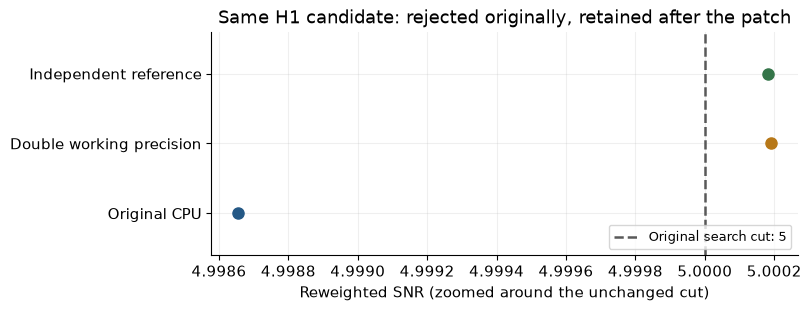

In [5]:
example = json.loads((evidence/'selection-crossing.json').read_text())
with np.load(evidence/'selection-crossing.npz', allow_pickle=False) as saved:
    captured = {name: saved[name].copy() for name in saved.files}
c, s = captured['corr'], captured['snr']
indices, edges = captured['indices'], captured['bins']
normalization = float(captured['norm'])
nbins = len(edges)-1
snr_term = (s.conj()*s).real
raw_snr = abs(s*normalization)
result = {label: (mod.shift_sum(Array(c), indices, edges)*nbins-snr_term)*normalization**2
          for label, mod in modules.items()}
direct = reference_power(c, indices, edges)
via_fft = fft_reference_power(c, indices, edges)
np.testing.assert_allclose(direct, via_fft, rtol=1e-11)
print('Max |direct / FFT reference difference|:', np.max(abs(direct/via_fft-1)))
reference = (direct*nbins-snr_term)*normalization**2
result['reference'] = reference.astype(np.float32)
dof = np.full(len(indices), 2*nbins-2, dtype=np.int64)
rank = {label: newsnr(raw_snr, value/dof) for label, value in result.items()}
j = int(example['point'])
assert indices[j] == example['sample']
np.testing.assert_allclose(reference[j], example['reference'], rtol=1e-12)
assert rank['upstream'][j] < 5 <= rank['arithmetic'][j]
assert rank['reference'][j] >= 5
comparison = pd.DataFrame({
    'chi-square': {label: value[j] for label, value in result.items()},
    'NewSNR': {label: value[j] for label, value in rank.items()}})
comparison['retained'] = comparison.NewSNR >= 5
print('Template hash:', example['template_hash'], '; GPS:', f"{example['gps']:.6f}")
display(comparison.style.format({'chi-square': '{:.8f}', 'NewSNR': '{:.8f}'}))

fig, ax = plt.subplots(figsize=(8, 3), layout='constrained')
titles = ['Original CPU', 'Double working precision', 'Independent reference']
for y, (label, color) in enumerate(zip(result, ['#245885', '#B77818', '#347549'])):
    ax.plot(rank[label][j], y, 'o', color=color, ms=8)
ax.axvline(5, color='0.35', ls='--', label='Original search cut: 5')
ax.set(yticks=range(3), yticklabels=titles, ylim=(-0.6, 2.6),
       xlabel='Reweighted SNR (zoomed around the unchanged cut)',
       title='Same H1 candidate: rejected originally, retained after the patch')
ax.ticklabel_format(axis='x', style='plain', useOffset=False)
ax.legend(loc='lower right', fontsize=9)
plt.show()

## CPU cost

The measurements below time the kernel only, excluding input construction, on one macOS arm64 host. Nine interleaved batches give median and interquartile range. The retained measurements compare only the original and double-precision implementations. They do not predict end-to-end search runtime.

[Timings](arithmetic_benchmark.csv) and [environment](arithmetic_benchmark_environment.json) cover short, uniform, captured and wide-bin layouts, complex64/complex128 inputs and 1, 2 and 5 selected samples. Reproduce this comparison with `python benchmark.py --variants upstream arithmetic --output arithmetic_benchmark.csv`.

In [6]:
timings = pd.read_csv('arithmetic_benchmark.csv')
selected = timings[(timings['shape'] == 'captured') &
                   (timings['dtype'] == 'complex64') &
                   timings['variant'].isin(['upstream', 'arithmetic'])]
display(selected[['npoints', 'variant', 'median_ms', 'q25_ms', 'q75_ms',
                  'ratio_to_upstream']].style.format(precision=3))

,npoints,variant,median_ms,q25_ms,q75_ms,ratio_to_upstream
24,1,upstream,1.063,1.039,1.087,1.000
25,1,arithmetic,1.099,1.084,1.121,1.035
26,2,upstream,1.858,1.838,1.926,1.000
27,2,arithmetic,1.168,1.123,1.188,0.628
28,5,upstream,1.746,1.670,1.915,1.000
29,5,arithmetic,2.453,2.434,2.493,1.405


The larger fixed-cut run establishes a concrete change in single-detector trigger admission. The independent reference agrees with the patched decision for every changed event. It does **not** establish a changed astrophysical detection, false-alarm rate or detection efficiency: those require a coincidence/background or injection study.

Double working precision reduces the demonstrated error, but the calculation remains approximate. The kernel still uses `3.141592653` for phases, and output and final wrapper arithmetic still round to float32. The full search is deterministic evidence from one selected bank and data segment; its observed fraction of changed decisions is not an estimate for other runs.